# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Job Replacement Dataset](https://www.kaggle.com/datasets/dmahajanbe23/ai-job-replacement-and-skill-shift-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai_job_replacement_2020_2026_v2.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


## last Five row

In [4]:
df.tail()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
14995,14995,HR Manager,Finance,Canada,2025,44.05,38.61,1.06,74458.30,76568.31,2.83,-17.88,96.56,7.94,1,Medium,22.555,2.83,18.787,3.497570
14996,14996,Software Engineer,Energy,India,2023,15.68,15.37,34.93,97728.22,94274.12,-3.53,18.14,37.83,22.79,5,Low,25.305,3.53,17.810,3.573472
14997,14997,Truck Driver,Transportation,Japan,2026,80.16,67.09,48.57,74801.26,79989.74,6.94,26.51,41.20,10.57,3,High,64.365,6.94,48.717,8.472912
14998,14998,Customer Support Rep,Transportation,USA,2020,34.54,37.05,49.30,124632.88,127378.53,2.20,10.36,92.09,2.76,3,Medium,41.920,2.20,29.266,0.953304
14999,14999,Mechanical Engineer,Retail,Australia,2023,47.62,43.18,19.67,63637.98,66559.86,4.59,16.29,79.94,49.98,5,Medium,33.645,4.59,26.326,23.800476


## Shape of our dataset

In [5]:
df.shape

(15000, 20)

## List out all columns

In [6]:
df.columns

Index(['job_id', 'job_role', 'industry', 'country', 'year',
       'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
       'salary_before_usd', 'salary_after_usd', 'salary_change_percent',
       'skill_demand_growth_percent', 'remote_feasibility_score',
       'ai_adoption_level', 'education_requirement_level',
       'automation_risk_category', 'skill_transition_pressure',
       'wage_volatility_index', 'reskilling_urgency_score',
       'ai_disruption_intensity'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

job_id                           int64
job_role                        object
industry                        object
country                         object
year                             int64
automation_risk_percent        float64
ai_replacement_score           float64
skill_gap_index                float64
salary_before_usd              float64
salary_after_usd               float64
salary_change_percent          float64
skill_demand_growth_percent    float64
remote_feasibility_score       float64
ai_adoption_level              float64
education_requirement_level      int64
automation_risk_category        object
skill_transition_pressure      float64
wage_volatility_index          float64
reskilling_urgency_score       float64
ai_disruption_intensity        float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

## Check Null Value

In [9]:
df.isnull().sum()

job_id                         0
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,4330.271354,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,0.000000,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,3749.750000,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,7499.500000,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,11249.250000,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,14999.000000,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

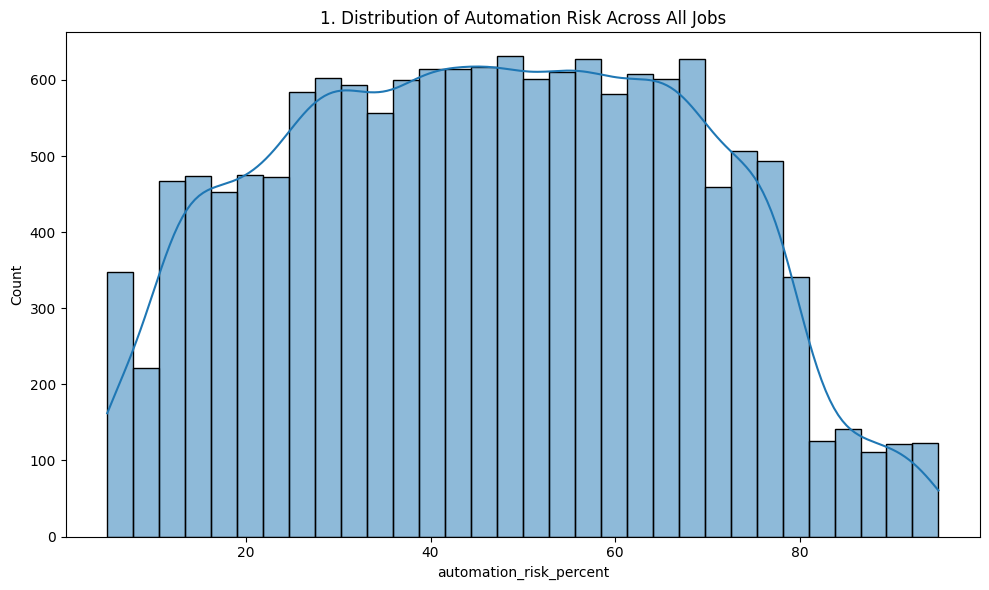

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['automation_risk_percent'], kde=True)
plt.title(f'{plot_no}. Distribution of Automation Risk Across All Jobs')
show_fig()
plot_no += 1

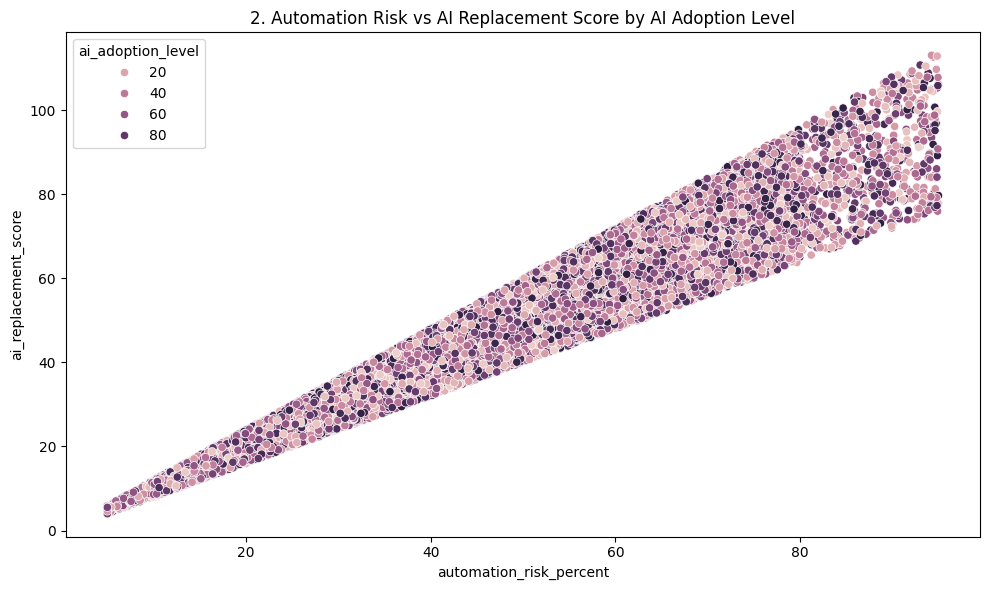

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='automation_risk_percent', y='ai_replacement_score', hue='ai_adoption_level')
plt.title(f'{plot_no}. Automation Risk vs AI Replacement Score by AI Adoption Level')
show_fig()
plot_no += 1

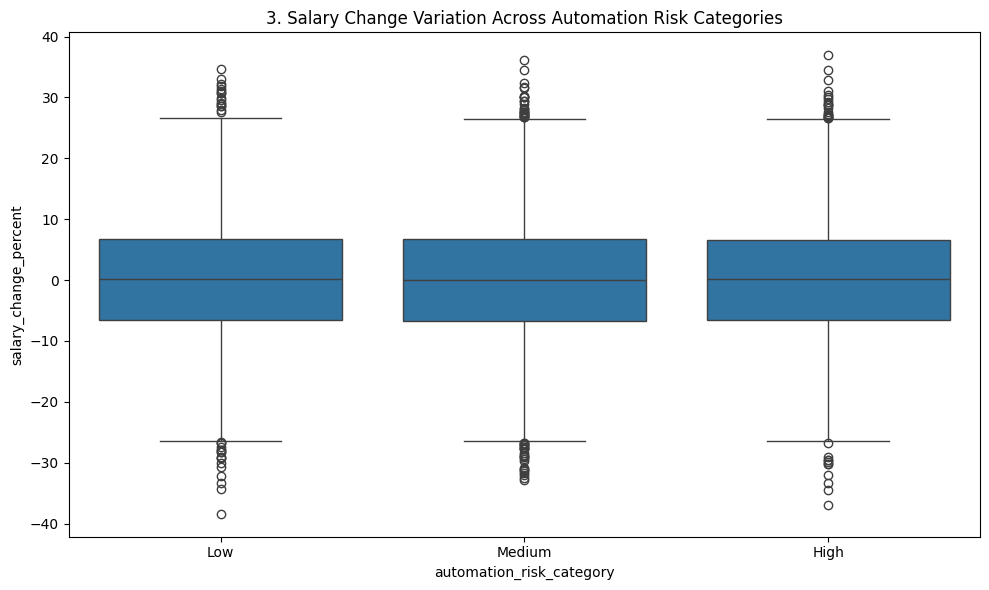

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='automation_risk_category', y='salary_change_percent')
plt.title(f'{plot_no}. Salary Change Variation Across Automation Risk Categories')
show_fig()
plot_no += 1

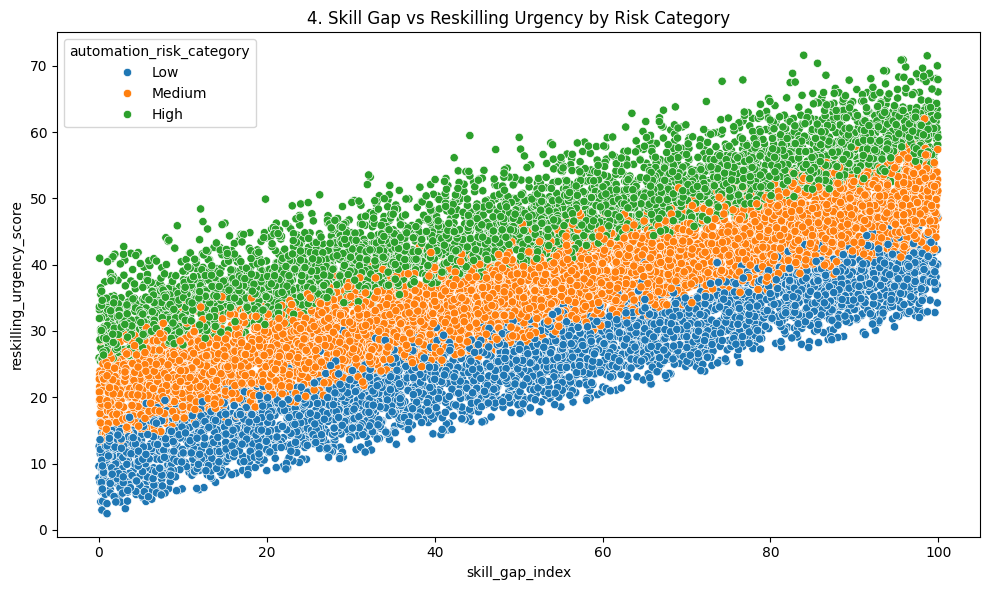

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='skill_gap_index', y='reskilling_urgency_score', hue='automation_risk_category')
plt.title(f'{plot_no}. Skill Gap vs Reskilling Urgency by Risk Category')
show_fig()
plot_no += 1

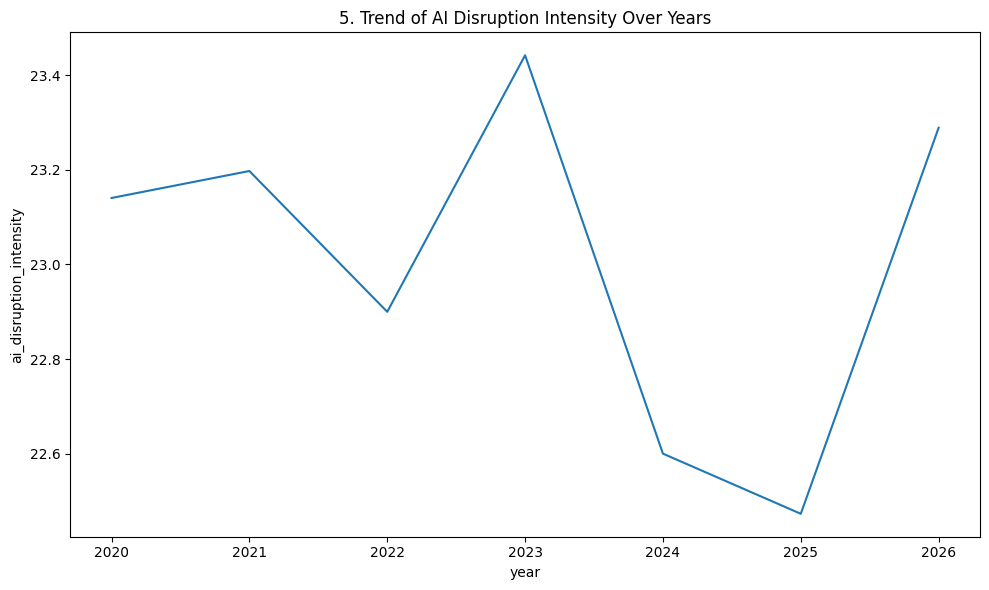

In [17]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('year')['ai_disruption_intensity'].mean().reset_index(), x='year', y='ai_disruption_intensity')
plt.title(f'{plot_no}. Trend of AI Disruption Intensity Over Years')
show_fig()
plot_no += 1

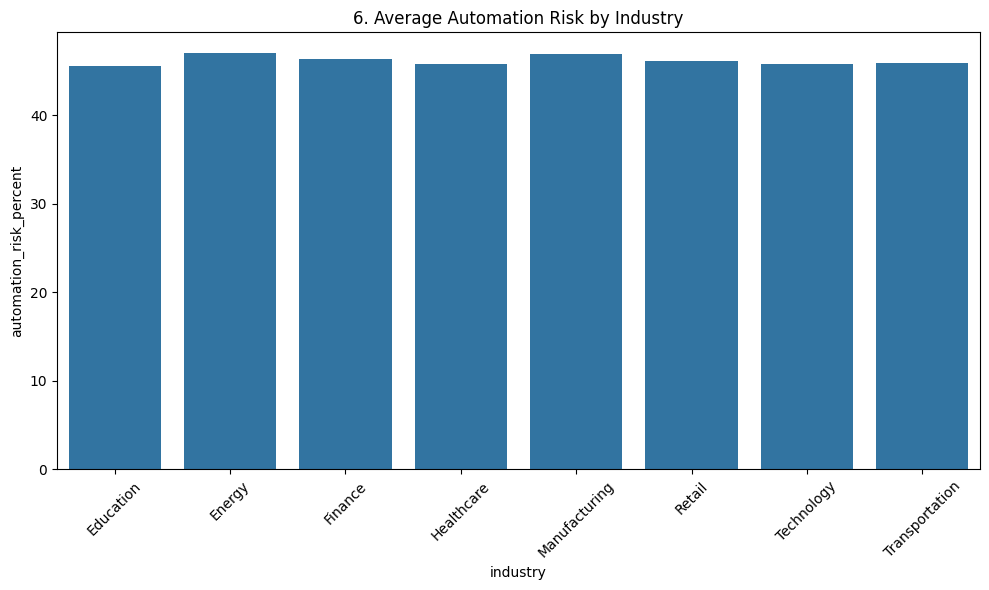

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df.groupby('industry')['automation_risk_percent'].mean().reset_index(), x='industry', y='automation_risk_percent')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Automation Risk by Industry')
show_fig()
plot_no += 1

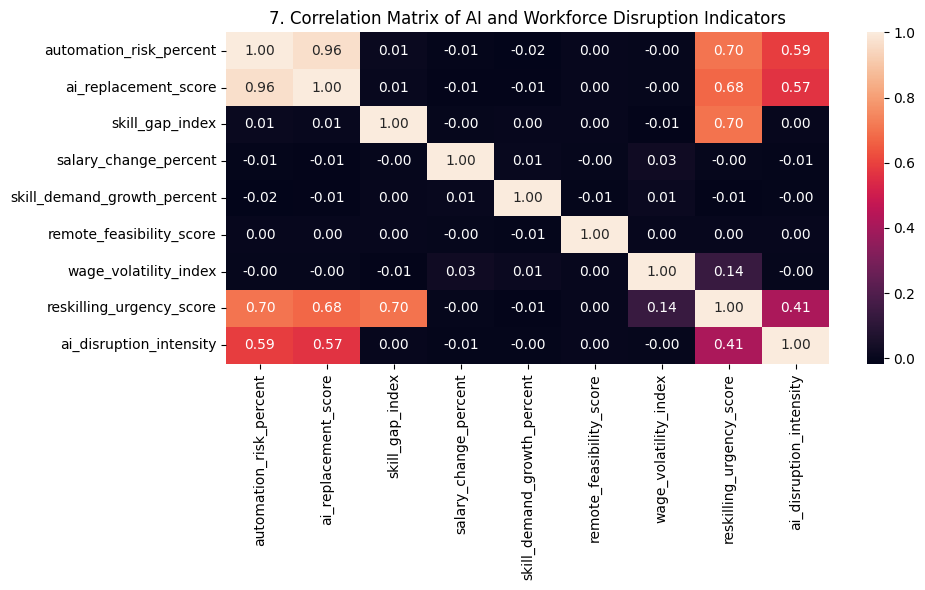

In [19]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df[['automation_risk_percent','ai_replacement_score','skill_gap_index','salary_change_percent','skill_demand_growth_percent','remote_feasibility_score','wage_volatility_index','reskilling_urgency_score','ai_disruption_intensity']].corr(), annot=True, fmt=".2f")
plt.title(f'{plot_no}. Correlation Matrix of AI and Workforce Disruption Indicators')
show_fig()
plot_no += 1

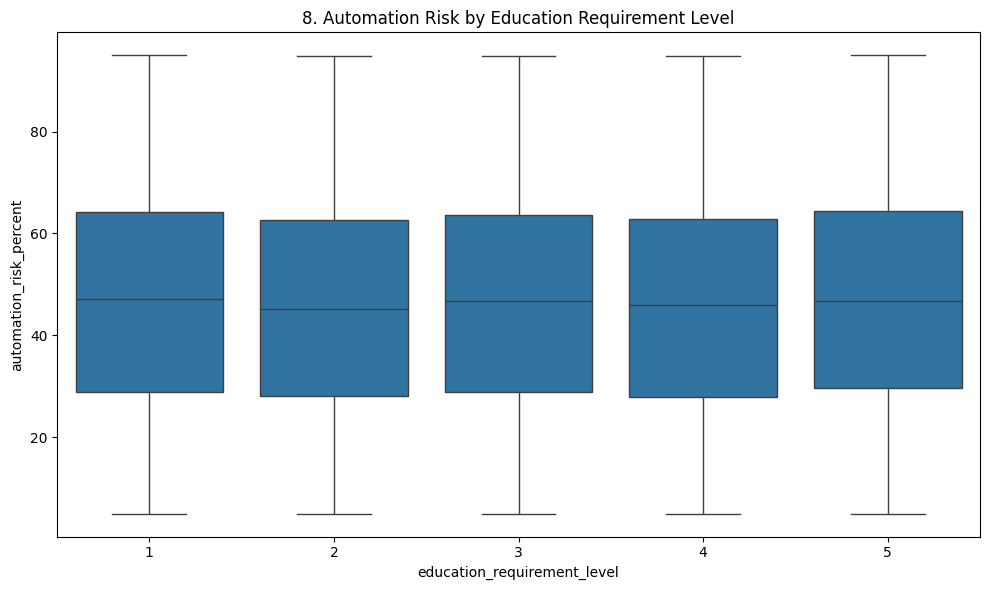

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='education_requirement_level', y='automation_risk_percent')
plt.title(f'{plot_no}. Automation Risk by Education Requirement Level')
show_fig()
plot_no += 1

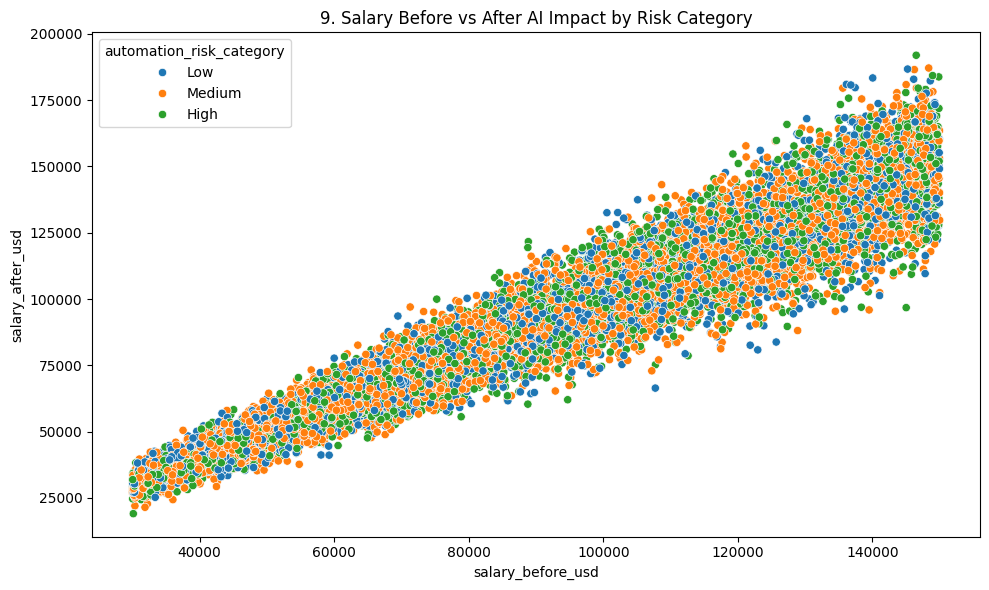

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='salary_before_usd', y='salary_after_usd', hue='automation_risk_category')
plt.title(f'{plot_no}. Salary Before vs After AI Impact by Risk Category')
show_fig()
plot_no += 1

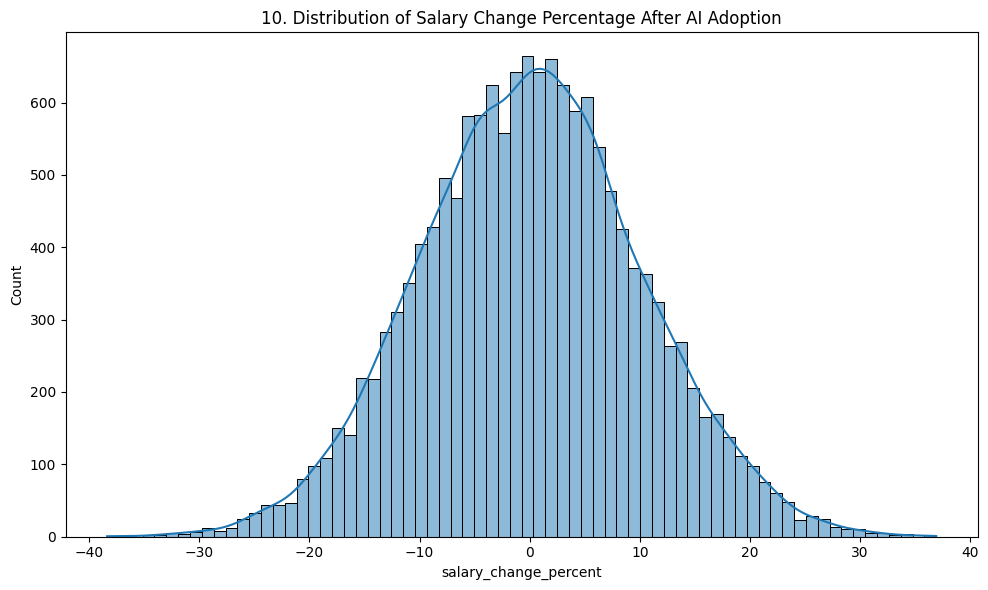

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['salary_change_percent'], kde=True)
plt.title(f'{plot_no}. Distribution of Salary Change Percentage After AI Adoption')
show_fig()
plot_no += 1

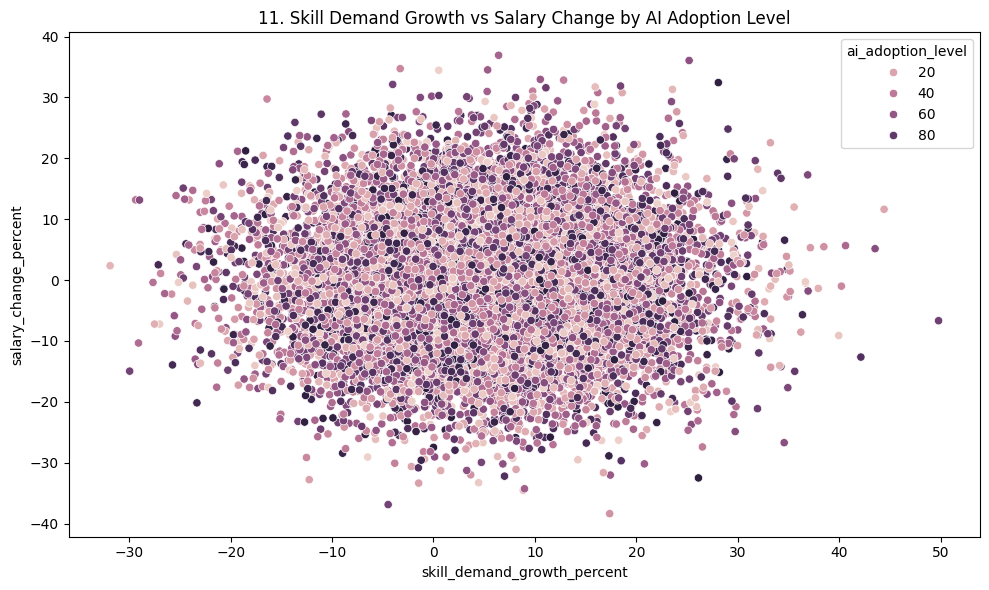

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='skill_demand_growth_percent', y='salary_change_percent', hue='ai_adoption_level')
plt.title(f'{plot_no}. Skill Demand Growth vs Salary Change by AI Adoption Level')
show_fig()
plot_no += 1

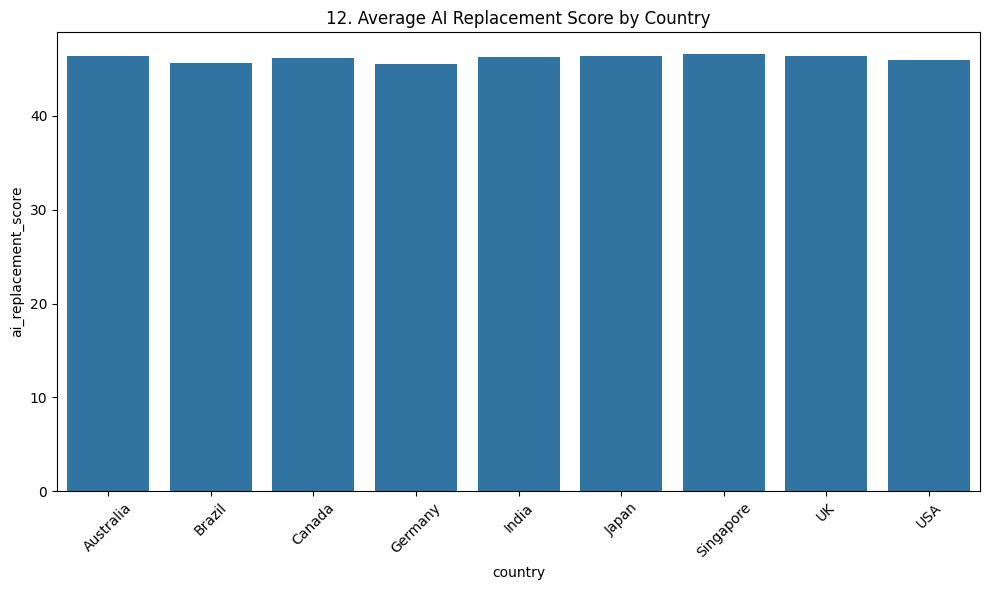

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df.groupby('country')['ai_replacement_score'].mean().reset_index(), x='country', y='ai_replacement_score')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average AI Replacement Score by Country')
show_fig()
plot_no += 1

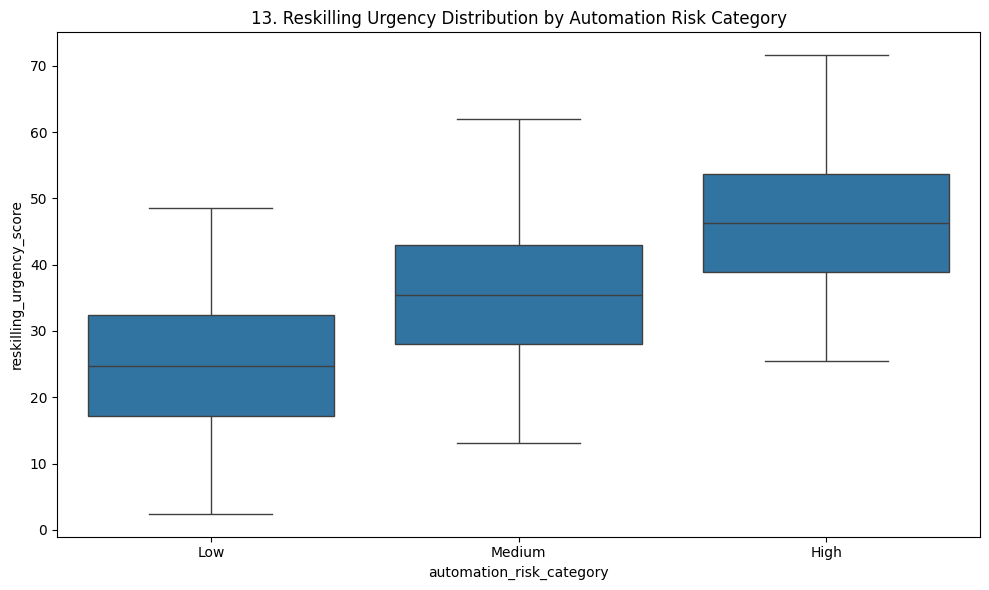

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='automation_risk_category', y='reskilling_urgency_score')
plt.title(f'{plot_no}. Reskilling Urgency Distribution by Automation Risk Category')
show_fig()
plot_no += 1

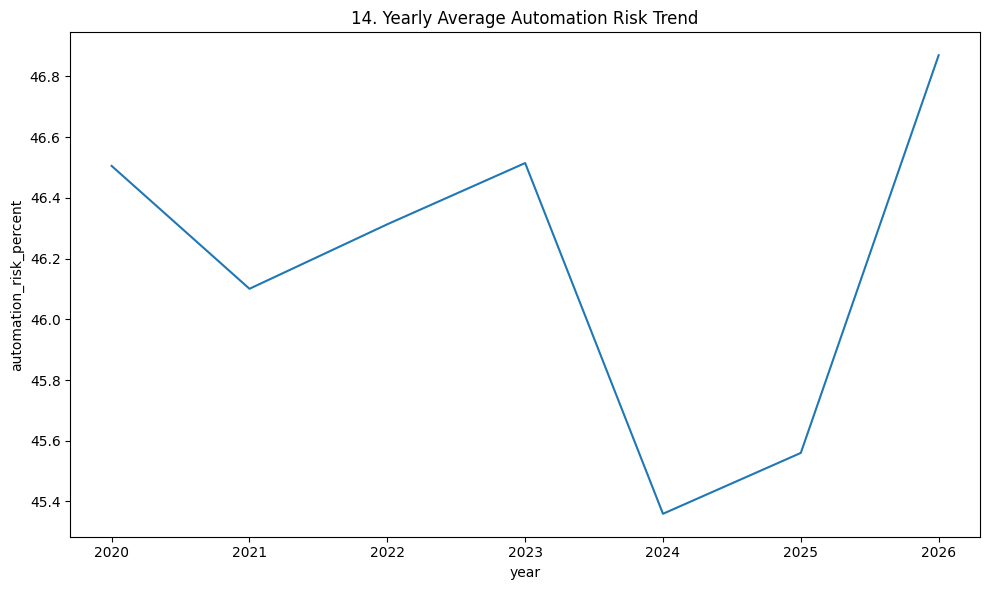

In [26]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('year')['automation_risk_percent'].mean().reset_index(), x='year', y='automation_risk_percent')
plt.title(f'{plot_no}. Yearly Average Automation Risk Trend')
show_fig()
plot_no += 1

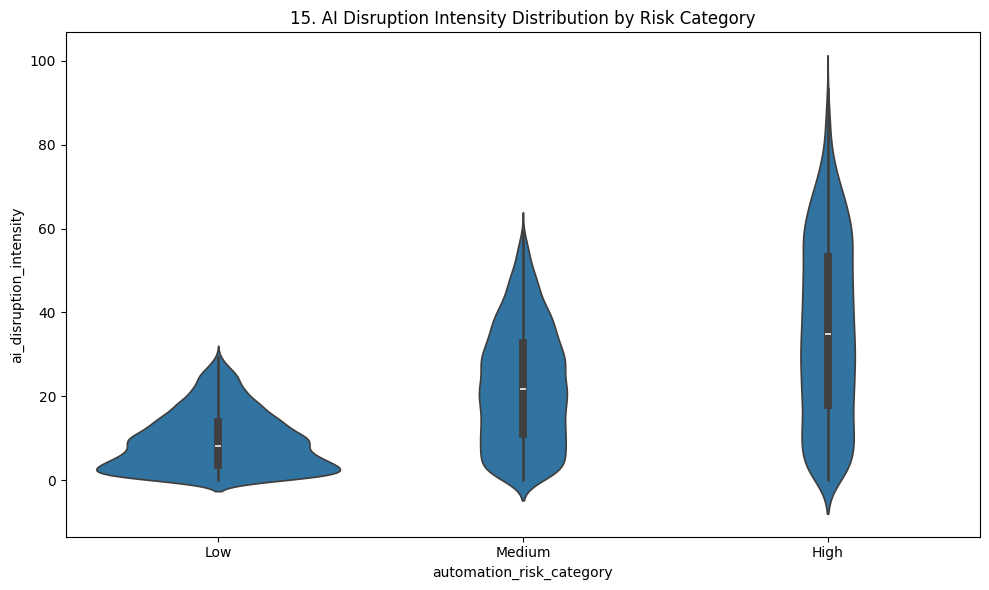

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='automation_risk_category', y='ai_disruption_intensity')
plt.title(f'{plot_no}. AI Disruption Intensity Distribution by Risk Category')
show_fig()
plot_no += 1

# Model Training

## Copy Data

In [28]:
data = df.copy()

### Encode categorical features

In [29]:
categorical_cols = data.select_dtypes(include='object').columns
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

## Define features and target (predict Automation Risk Category)

In [30]:
X = data.drop(['automation_risk_category'], axis=1)
y = data['automation_risk_category']

## Train-test split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale features

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Support Vector Machine model

In [33]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Predictions

In [34]:
y_pred = model.predict(X_test)

## Accuracy score

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy Score:", accuracy)

Model Accuracy Score: 0.9693333333333334


## Confusion Matrix

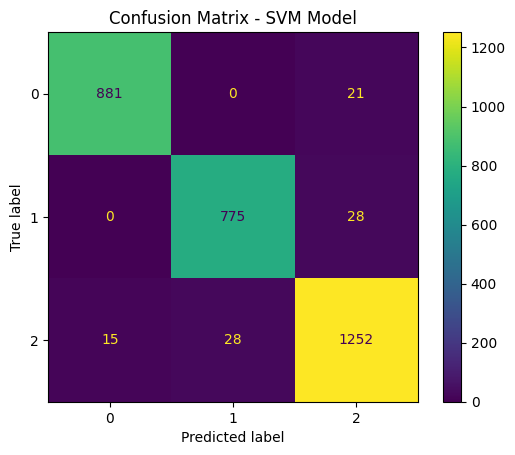

In [36]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM Model")
plt.show()